In [1]:
import os, sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numbers
import pickle as pkl
import warnings
warnings.filterwarnings("ignore")
from inDecay import analysis_fn
def read_pkl(path):
    with open(path, 'rb') as f:
        Y = pkl.load(f)
    f.close()
    return Y

pj=os.path.join
def read_json(path):
    with open(path, 'r') as f:
        js = json.load(f)
        f.close()
    return js

In [2]:
os.getcwd()
# os.chdir(...) removed for portability — run this notebook from the repo root


In [3]:
perform_js = []

fix_settings = ['None']#, 'del_regressor[:1]', 'del_regressor[:2]']
cells = ['BOB', 'E14TG2A']
for cell in cells:
    data_dir = f"results/Transfer/C500/CHO-{cell}"
    file =  os.listdir(data_dir)
    for path in file:
        if "Baseline" in path:
            N_sample = 0
        elif "bench" in path:
            N_sample = -1
        else:
            N_sample = int(os.path.basename(path).split("-")[0].split('_')[-1][1:])
        
        raw_dict = read_json(os.path.join(data_dir, path))        
        perform_dict =  {k: v for k, v in raw_dict.items() if isinstance(v, numbers.Number)}

        perform_dict['N_sample'] = N_sample
        perform_dict['cell'] = cell
        perform_js.append(perform_dict)

In [4]:
performance = pd.json_normalize(perform_js).sort_values('N_sample', ascending=True)
performance['N_sample'] = performance['N_sample'].astype(str)

In [5]:
plot_metrics = ['R2 of Frameshift Ratio', 'Major(0.15) event recall',
       'Top5 event recall',
       'Top5 Kendall Tau',
       'KLD_IDL']

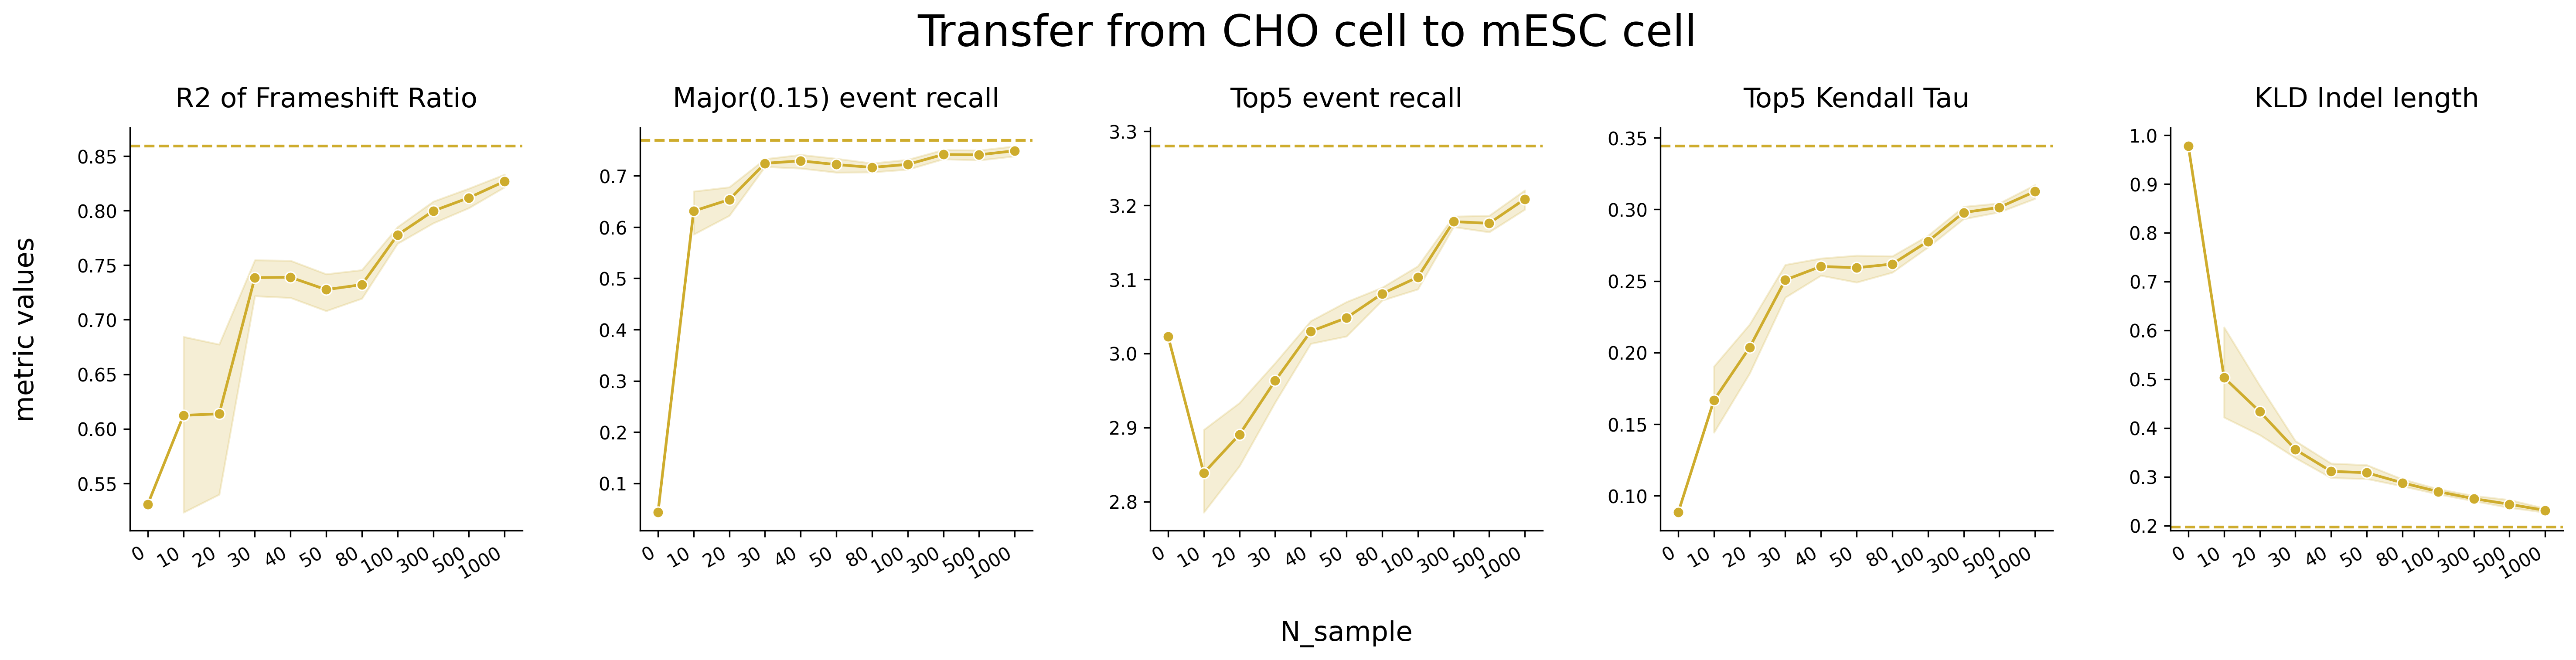

In [6]:
BOB_perform = performance.query("`cell` == 'E14TG2A'")
BOB_perform.rename(columns={'Top5 events tau':'Top5 Kendall Tau', 'R2 of Frameshift ratio': 'R2 of Frameshift Ratio', 'Top5 events recall': 'Top5 event recall'}, inplace=True)
fig, axs = plt.subplots(1, 5, figsize=(24, 4), dpi=300, gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
axs = axs.flatten()

for i, metric in enumerate(plot_metrics):
    sns.lineplot(data=BOB_perform.query("`N_sample` != '-1'"), x='N_sample', y=metric, marker='o', ax=axs[i], color='#CEAC2D')
    axs[i].legend('', frameon=False)
    sns.despine(ax=axs[i])
    axs[i].set_title(metric.replace('_IDL', ' Indel length') + "\n", fontsize=15, y=0.95)
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=60, ha='right')

    vals = BOB_perform.query("`N_sample` == '-1'")[metric].values
    if len(vals) > 0:
        axs[i].axhline(vals[0], ls='--', color='#CEAC2D')

    if i != 2:
        axs[i].set_xlabel("")
    else:
        axs[i].set_xlabel("\nN_sample", fontsize=15)
    if i != 0:
        axs[i].set_ylabel("")
    else:
        axs[i].set_ylabel("metric values\n", fontsize=15)

    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=30, ha='right')

fig.suptitle("Transfer from CHO cell to mESC cell", fontsize=24, y=1.1)
plt.show()


Text(0.5, 1.1, 'Transfer from CHO cell to iPSC cell ')

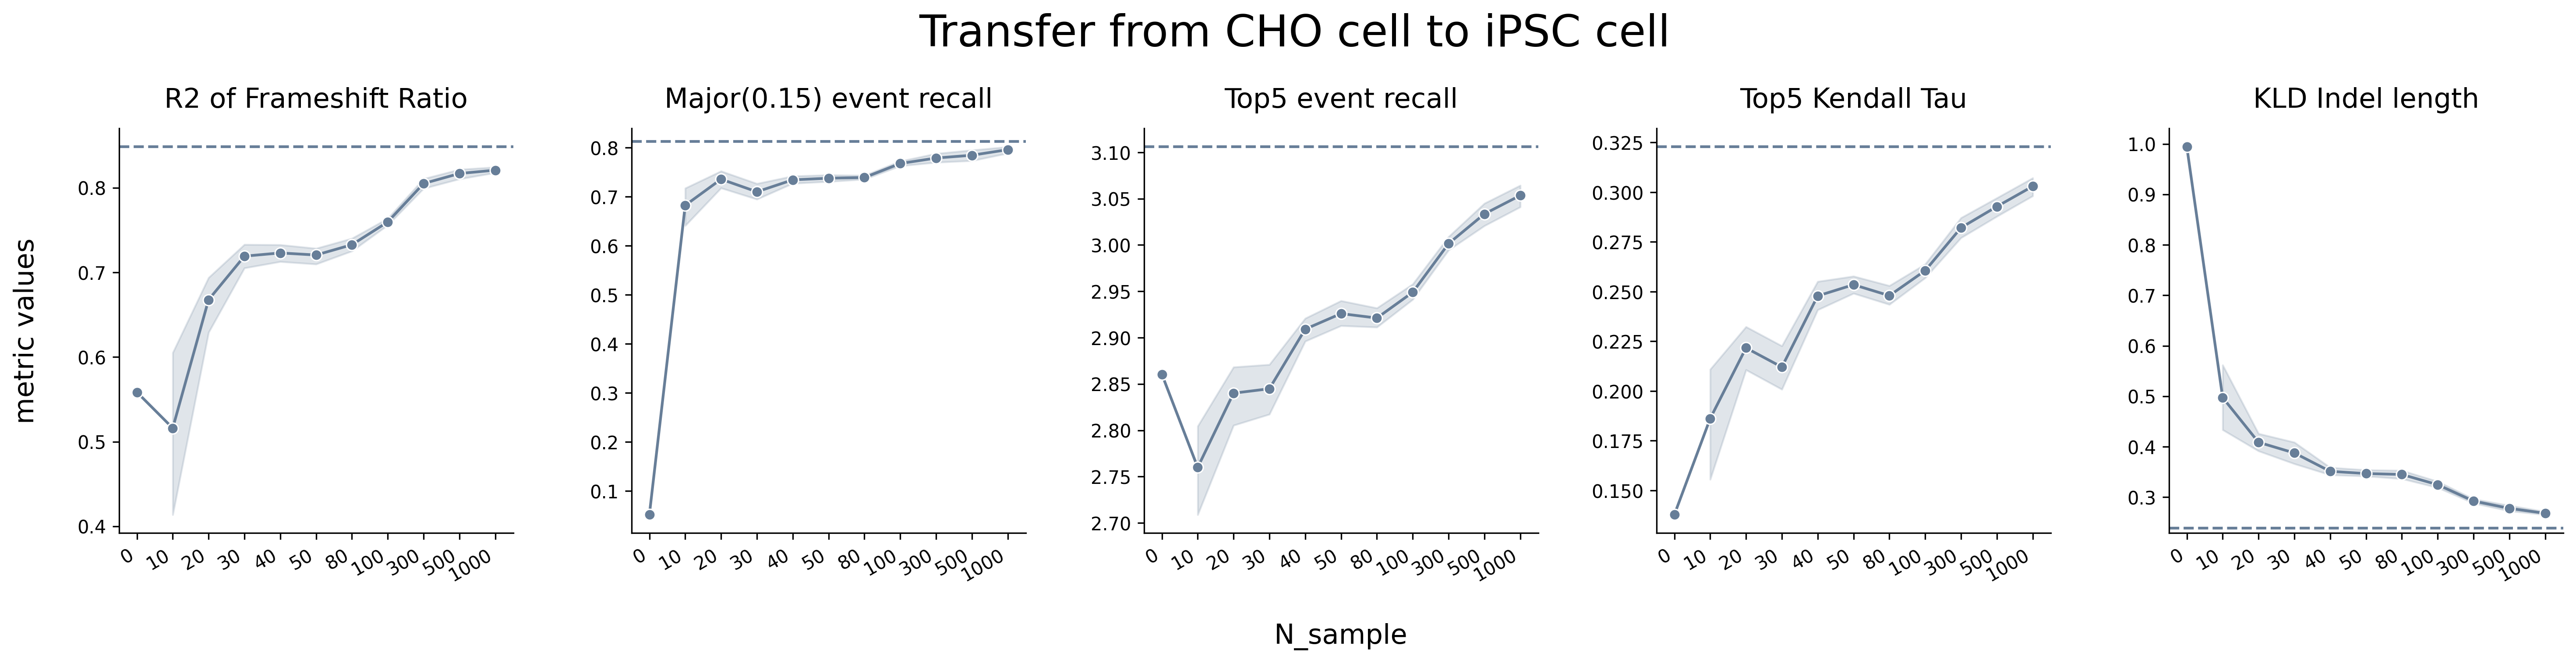

In [7]:
BOB_perform = performance.query("`cell` == 'BOB'")
BOB_perform.rename(columns={'Top5 events tau':'Top5 Kendall Tau', 'R2 of Frameshift ratio': 'R2 of Frameshift Ratio', 'Top5 events recall': 'Top5 event recall'}, inplace=True)
fig, axs = plt.subplots(1, 5, figsize=(24, 4), dpi=300, gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
axs = axs.flatten()

for i, metric in enumerate(plot_metrics):
    sns.lineplot(data=BOB_perform.query("`N_sample` != '-1'"), x='N_sample', y=metric, marker='o', ax=axs[i], color='#677E98')
    axs[i].legend('', frameon=False)
    sns.despine(ax=axs[i])
    axs[i].set_title(metric.replace('_IDL', ' Indel length') + "\n", fontsize=15, y=0.95)
    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=60, ha='right')

    vals = BOB_perform.query("`N_sample` == '-1'")[metric].values
    if len(vals) > 0:
        axs[i].axhline(vals[0], ls='--', color='#677E98')

    if i != 2:
        axs[i].set_xlabel("")
    else:
        axs[i].set_xlabel("\nN_sample", fontsize=15)
    if i != 0:
        axs[i].set_ylabel("")
    else:
        axs[i].set_ylabel("metric values\n", fontsize=15)

    axs[i].set_xticklabels(axs[i].get_xticklabels(), rotation=30, ha='right')

fig.suptitle("Transfer from CHO cell to iPSC cell ", fontsize=24, y=1.1)